In [79]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

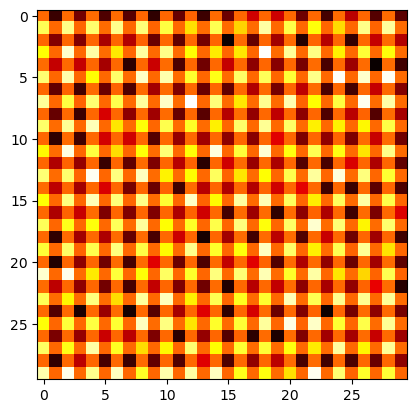

In [80]:
terrain = np.load("01_terrain.npy")
plt.imshow(terrain, cmap = 'hot', interpolation = 'nearest')
plt.show()

In [81]:
A = (15, 15)
B = (29, 29)

In [82]:
def read_input():
    i, j = input().replace(' ', '').split(',')
    return int(i), int(j)

In [ ]:
def manhattn(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1]) 

def get_neighbours(u, n, m):
    neighbours = []
    i, j = u[0], u[1]

    moves = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    for move in moves:
        vi = i + move[0]
        vj = j + move[1]

        if 0 <= vi < n and 0 <= vj < m:
            neighbours.append((vi, vj))

    return neighbours

def astar(matrix, start, end, h):
    n, m = matrix.shape

    open_list = set([start])
    closed_list = set()

    g = defaultdict(lambda: float("inf"))
    g[start] = 0

    parent = {start: None}

    while open_list:
        u = min(open_list, key = lambda v: g[v] + h(v, end))

        if u is None:
            break

        if u == end:
            print('Path found')

            path = []
            
            while u is not None:
                path.append(u)
                u = parent[u]

            path.reverse()
            return path

        for v in get_neighbours(u, n, m):

            u_height = matrix[u[0], u[1]]
            v_height = matrix[v[0], v[1]]

            if u_height >= v_height:
                time = 0.7 * (u_height - v_height)
            else:
                time = 2 * (v_height - u_height)

            if v not in open_list and v not in closed_list:
                open_list.add(v)
                parent[v] = u
                g[v] = g[u] + time
            else:
                if g[v] > g[u] + time:
                    g[v] = g[u] + time
                    parent[v] = u

                    if v in closed_list:
                        closed_list.remove(v)
                        open_list.add(v)
            
        open_list.remove(u)
        closed_list.add(u)

    return []

def compute_time(terrain, path):
    time = 0.0

    n = len(path)

    for i in range(n-1):
        u = path[i]
        v = path[i+1]

        u_height = terrain[u[0], u[1]]
        v_height = terrain[v[0], v[1]]

        if u_height >= v_height:
            time += 0.7 * (u_height - v_height)
        else:
            time += 2 * (v_height - u_height)

    return time

In [84]:
path = astar(terrain, A, B, manhattn)
print(path)
time = compute_time(terrain, path)
print(time)

Path found
[(15, 15), (14, 15), (14, 16), (14, 17), (14, 18), (14, 19), (14, 20), (14, 21), (14, 22), (15, 22), (15, 23), (16, 23), (17, 23), (18, 23), (18, 24), (19, 24), (20, 24), (21, 24), (21, 25), (21, 26), (22, 26), (22, 27), (23, 27), (24, 27), (25, 27), (26, 27), (26, 28), (26, 29), (27, 29), (28, 29), (29, 29)]
2436.4839334157305
